# Clasificación Multi-Clase de Radiografías de Tórax con MLP
## ChestX6 Dataset — 6 Clases de Enfermedades Pulmonares

**Dataset:** ChestX6: Multi-Class X-ray Dataset (Kaggle)  
**Framework:** TensorFlow / Keras  
**Tarea:** Clasificación multiclase (6 clases)  
**Semana:** 1 — Implementación de Perceptrón Multicapa (MLP)
**Grupo2:** Nataly Lanchimba / Dario Herrera / Jordy Cevallos  

---
### Clases objetivo:
| # | Clase | Descripción |
|---|-------|-------------|
| 0 | Normal | Pulmones sanos, campos pulmonares claros |
| 1 | Pneumonia-Bacterial | Infección bacteriana, consolidaciones lobares densas |
| 2 | Pneumonia-Viral | Infecciones virales no-COVID, infiltrados intersticiales |
| 3 | COVID-19 | SARS-CoV-2, opacidades bilaterales en vidrio esmerilado |
| 4 | Tuberculosis | Infección por M. tuberculosis, cavitaciones en lóbulos superiores |
| 5 | Emphysema | EPOC, hiperinflación y diafragma aplanado |

---
## 1. Instalación y Configuración del Entorno

In [ ]:
# Instalar kagglehub
#!pip install kagglehub -q
#!pip install scikit-learn matplotlib seaborn tensorflow -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.1.61 requires filetype, which is not installed.
roboflow 1.1.61 requires opencv-python-headless==4.10.0.84, which is not installed.
roboflow 1.1.61 requires pillow-heif>=0.18.0, which is not installed.
roboflow 1.1.61 requires python-dotenv, which is not installed.
roboflow 1.1.61 requires requests-toolbelt, which is not installed.
roboflow 1.1.61 requires idna==3.7, but you have idna 3.11 which is incompatible.


---
## 2. Importación de Librerías

In [1]:
# ── Librerías base ──────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Scikit-learn (métricas) ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.10.0
GPU disponible: True


---
## 3. Descarga del Dataset

In [2]:
import kagglehub

# Descargar dataset desde Kaggle
path = kagglehub.dataset_download("mohamedasak/chest-x-ray-6-classes-dataset")
print("Path to dataset files:", path)

# Explorar la estructura de directorios
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')

Path to dataset files: C:\Users\jordi\.cache\kagglehub\datasets\mohamedasak\chest-x-ray-6-classes-dataset\versions\1
1/
  chest-xray/
    test/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/
    train/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/
    val/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/


In [3]:
# Definir rutas de los conjuntos de datos
TRAIN_DIR = os.path.join(path, 'chest-xray/train')
VAL_DIR   = os.path.join(path, 'chest-xray/val')
TEST_DIR  = os.path.join(path, 'chest-xray/test')

# Nombres de las clases
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Clases encontradas ({NUM_CLASSES}): {CLASS_NAMES}")

Clases encontradas (6): ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']


---
## 4. Análisis Exploratorio de Datos (EDA)
### 4.1 Ficha Técnica del Dataset

In [4]:
# Contar imágenes por clase y por split
def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)
        if os.path.exists(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Tabla resumen
ficha = pd.DataFrame({
    'Train':      train_counts,
    'Validation': val_counts,
    'Test':       test_counts
})
ficha['Total'] = ficha.sum(axis=1)
ficha.loc['TOTAL'] = ficha.sum()

print("═" * 55)
print("       FICHA TÉCNICA — ChestX6 Dataset")
print("═" * 55)
print(f"  Modalidad:         Radiografía de tórax")
print(f"  Espacio de color:  Escala de grises (1 canal)")
print(f"  Resolución:        224 × 224 píxeles")
print(f"  Formato:           JPG / PNG")
print(f"  Nº de clases:      {NUM_CLASSES}")
print(f"  Total imágenes:    {int(ficha.loc['TOTAL', 'Total']):,}")
print("═" * 55)
print(ficha.to_string())

═══════════════════════════════════════════════════════
       FICHA TÉCNICA — ChestX6 Dataset
═══════════════════════════════════════════════════════
  Modalidad:         Radiografía de tórax
  Espacio de color:  Escala de grises (1 canal)
  Resolución:        224 × 224 píxeles
  Formato:           JPG / PNG
  Nº de clases:      6
  Total imágenes:    18,036
═══════════════════════════════════════════════════════
                     Train  Validation  Test  Total
Covid-19              2417         300   300   3017
Emphysema             2050         250   250   2550
Normal                2671         300   300   3271
Pneumonia-Bacterial   2400         300   300   3000
Pneumonia-Viral       2413         300   300   3013
Tuberculosis          2600         298   287   3185
TOTAL                14551        1748  1737  18036


### 4.2 Distribución de Clases

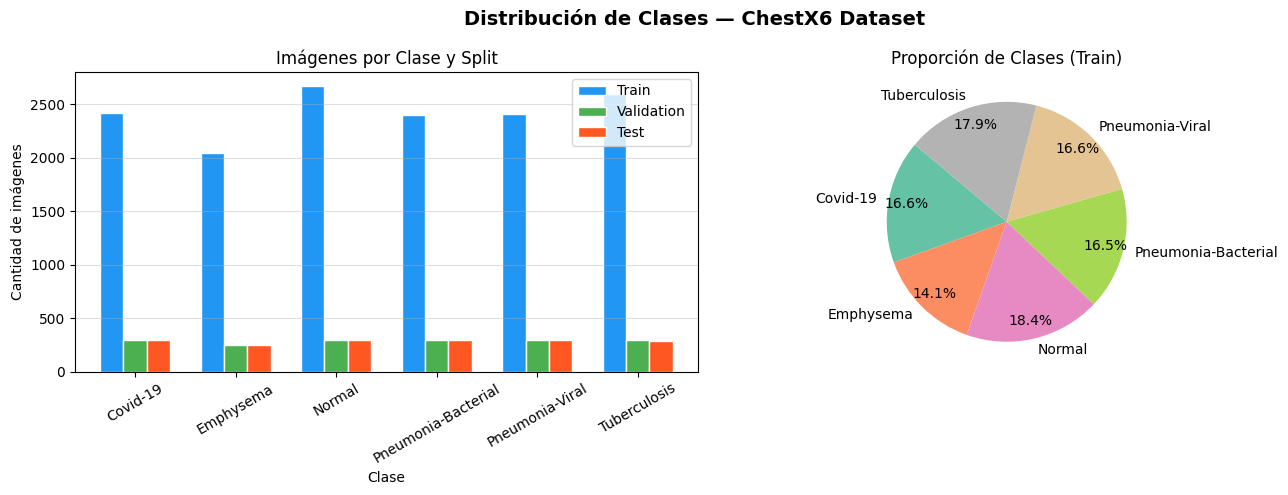

✓ El dataset está relativamente balanceado entre clases.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases — ChestX6 Dataset', fontsize=14, fontweight='bold')

# Barplot por split
ficha_plot = ficha.drop('TOTAL').drop('Total', axis=1)
ficha_plot.plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF5722'],
                edgecolor='white', width=0.7)
axes[0].set_title('Imágenes por Clase y Split')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Pie chart del total de entrenamiento
train_vals = list(train_counts.values())
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
axes[1].pie(train_vals, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85)
axes[1].set_title('Proporción de Clases (Train)')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ El dataset está relativamente balanceado entre clases.")

### 4.3 Visualización de Muestras por Clase

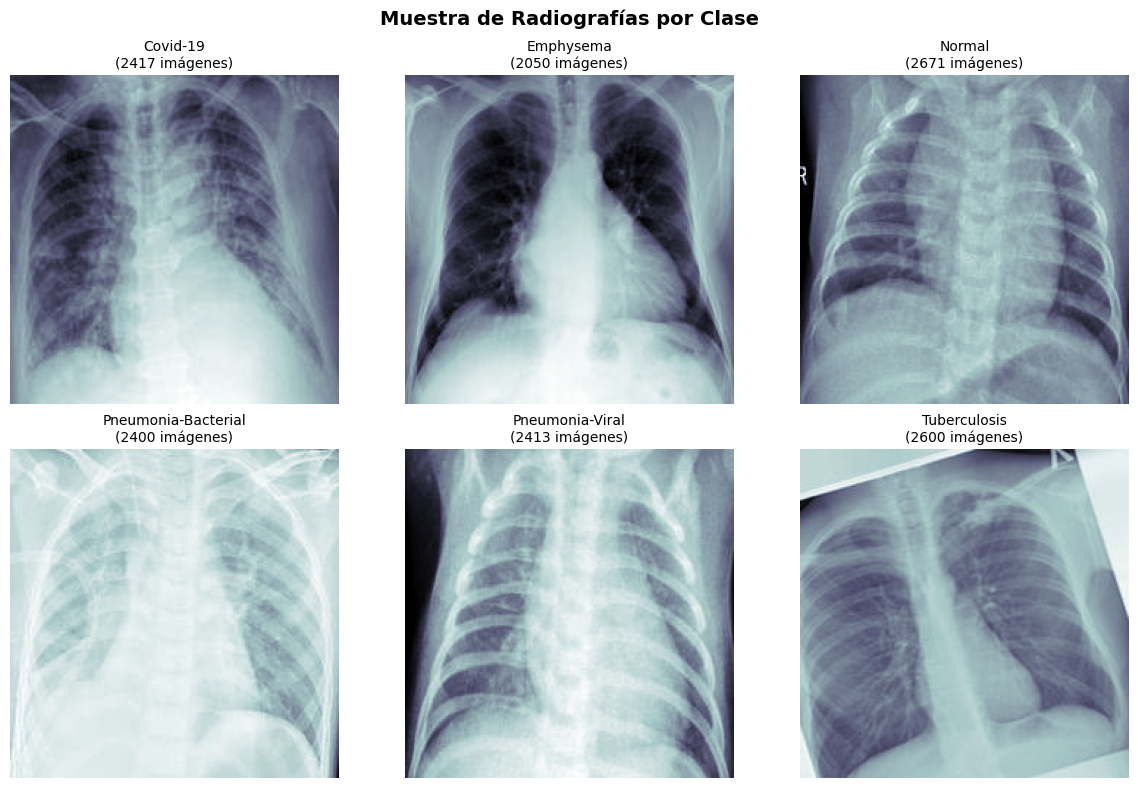

In [6]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Muestra de Radiografías por Clase', fontsize=14, fontweight='bold')

for idx, (cls, ax) in enumerate(zip(CLASS_NAMES, axes.flat)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, img_file),
                   color_mode='grayscale', target_size=(224, 224))
    ax.imshow(np.array(img), cmap='bone')
    ax.set_title(f'{cls}\n({train_counts[cls]} imágenes)', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Preprocesamiento y División de Datos

> **Justificación del diseño:**  
> El dataset ya viene pre-dividido en `train/val/test` (≈80.6% / 9.7% / 9.6%), lo que elimina el riesgo de *data leakage*. Se respeta esta división oficial del dataset.  
> 
> **Redimensionamiento:** Se usan imágenes de **64×64** píxeles en lugar de 224×224 para el MLP. Esto reduce el vector de entrada de 50,176 a **4,096 features**, haciendo el entrenamiento viable sin GPU de alto rendimiento, mientras conserva suficiente información diagnóstica.  
> 
> **Normalización:** División por 255.0 para mapear píxeles al rango [0, 1], acelerando la convergencia del gradiente descendente.

In [7]:
# ── Parámetros de configuración ──────────────────────────────────────────────
IMG_SIZE    = 64          # Redimensionar a 64×64 para MLP
BATCH_SIZE  = 64
EPOCHS      = 40
LR_INICIAL  = 1e-3

# ── Generadores de datos con normalización ───────────────────────────────────
# Train: incluye aumento de datos leve para mejorar generalización
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

# Val y Test: solo normalización (sin augmentation)
eval_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Generadores
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✓ Configuración completada:")
print(f"  • Tamaño de imagen: {IMG_SIZE}×{IMG_SIZE} → vector de {IMG_SIZE*IMG_SIZE} features")
print(f"  • Train: {train_gen.samples:,} imágenes | {train_gen.samples//BATCH_SIZE} batches")
print(f"  • Val:   {val_gen.samples:,} imágenes")
print(f"  • Test:  {test_gen.samples:,} imágenes")
print(f"  • Clases: {train_gen.class_indices}")

Found 14551 images belonging to 6 classes.
Found 1748 images belonging to 6 classes.
Found 1737 images belonging to 6 classes.

✓ Configuración completada:
  • Tamaño de imagen: 64×64 → vector de 4096 features
  • Train: 14,551 imágenes | 227 batches
  • Val:   1,748 imágenes
  • Test:  1,737 imágenes
  • Clases: {'Covid-19': 0, 'Emphysema': 1, 'Normal': 2, 'Pneumonia-Bacterial': 3, 'Pneumonia-Viral': 4, 'Tuberculosis': 5}


---
## 6. Arquitectura del MLP

### 6.1 Diseño de la red

| Capa | Tipo | Neuronas | Activación | Regularización |
|------|------|----------|------------|----------------|
| Input | Flatten | 4,096 | — | — |
| Dense 1 | Hidden | 1,024 | ReLU | BatchNorm + Dropout(0.4) |
| Dense 2 | Hidden | 512 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 3 | Hidden | 256 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 4 | Hidden | 128 | ReLU | Dropout(0.2) |
| Output | Softmax | 6 | Softmax | — |

**Justificación de decisiones:**
- **ReLU**: Evita el problema del gradiente desaparecido, convergencia rápida
- **Softmax**: Salida de probabilidades para clasificación multiclase
- **Dropout**: Regularización para prevenir overfitting (imágenes médicas son propensas a sobreajuste con MLP)
- **BatchNormalization**: Estabiliza el entrenamiento y permite tasas de aprendizaje más altas
- **Loss: Categorical Crossentropy**: Estándar para clasificación multiclase con one-hot encoding
- **Optimizer: Adam (lr=1e-3)**: Convergencia rápida y adaptativa

In [ ]:
def build_mlp(input_dim, num_classes, dropout_rates=[0.4, 0.3, 0.3, 0.2],
              use_batchnorm=True, learning_rate=1e-3):
    """
    Construye un MLP para clasificación multiclase de radiografías.
    
    Args:
        input_dim    : Dimensión del vector de entrada (H*W*C)
        num_classes  : Número de clases de salida
        dropout_rates: Lista con tasa de dropout por capa oculta
        use_batchnorm: Batch Normalization
        learning_rate: Tasa de aprendizaje inicial para Adam
    """
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name='input_img')
    x = layers.Flatten(name='flatten')(inp)
    
    # Configuración de capas ocultas
    hidden_units = [1024, 512, 256, 128]
    
    for i, (units, drop) in enumerate(zip(hidden_units, dropout_rates)):
        x = layers.Dense(
            units,
            kernel_initializer='he_normal',  # Inicialización óptima para ReLU
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'dense_{i+1}'
        )(x)
        if use_batchnorm and i < 2:  # BatchNorm en las primeras capas
            x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation('relu', name=f'relu_{i+1}')(x)
        x = layers.Dropout(drop, seed=SEED, name=f'dropout_{i+1}')(x)
    
    # Capa de salida
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs=inp, outputs=out, name='MLP_ChestX6')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model


# Construir el modelo principal
model = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
model.summary()

Model: "MLP_ChestX6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_img (InputLayer)      [(None, 64, 64, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense_1 (Dense)             (None, 1024)              4195328   
                                                                 
 bn_1 (BatchNormalization)   (None, 1024)              4096      
                                                                 
 relu_1 (Activation)         (None, 1024)              0         
                                                                 
 dropout_1 (Dropout)         (None, 1024)              0         
                                                                 
 dense_2 (Dense)             (None, 512)               

In [35]:
# Mostrar parámetros totales de forma clara
total_params = model.count_params()
print(f"\n Resumen de parámetros:")
print(f"  • Parámetros totales:     {total_params:>12,}")
print(f"  • Parámetros entrenables: {sum(np.prod(w.shape) for w in model.trainable_weights):>12,}")
print(f"  • Memoria aprox. (MB):    {total_params * 4 / 1024**2:>12.1f}")


 Resumen de parámetros:
  • Parámetros totales:        4,891,270
  • Parámetros entrenables:    4,888,198
  • Memoria aprox. (MB):            18.7


---
## 7. Entrenamiento del Modelo
### 7.1 Callbacks de entrenamiento

In [10]:
# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Detiene el entrenamiento si val_loss no mejora en 8 épocas
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce lr si val_loss no mejora en 4 épocas (learning rate scheduler)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    # Guarda el mejor modelo
    ModelCheckpoint(
        'best_mlp_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("✓ Callbacks configurados:")
print("  • EarlyStopping     (patience=8, restaura mejores pesos)")
print("  • ReduceLROnPlateau (patience=4, factor=0.5)  ← Learning Rate Scheduler")
print("  • ModelCheckpoint   (guarda mejor val_accuracy)")

✓ Callbacks configurados:
  • EarlyStopping     (patience=8, restaura mejores pesos)
  • ReduceLROnPlateau (patience=4, factor=0.5)  ← Learning Rate Scheduler
  • ModelCheckpoint   (guarda mejor val_accuracy)


In [36]:
# ── Entrenamiento ────────────────────────────────────────────────────────────
print("Iniciando entrenamiento del MLP...")
print(f"   Épocas máx: {EPOCHS} | Batch: {BATCH_SIZE} | LR inicial: {LR_INICIAL}")
print("-" * 60)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Entrenamiento completado en {len(history.history['loss'])} épocas")

Iniciando entrenamiento del MLP...
   Épocas máx: 40 | Batch: 64 | LR inicial: 0.001
------------------------------------------------------------
Epoch 1/40
228/228 [==============================] - 20s 85ms/step - loss: 0.5981 - accuracy: 0.8125 - precision: 0.8321 - recall: 0.7889 - val_loss: 0.6524 - val_accuracy: 0.7878 - val_precision: 0.8089 - val_recall: 0.7626 - lr: 6.2500e-05
Epoch 2/40
228/228 [==============================] - 12s 52ms/step - loss: 0.5980 - accuracy: 0.8114 - precision: 0.8335 - recall: 0.7886 - val_loss: 0.6407 - val_accuracy: 0.7963 - val_precision: 0.8210 - val_recall: 0.7689 - lr: 6.2500e-05
Epoch 3/40
228/228 [==============================] - 12s 52ms/step - loss: 0.5924 - accuracy: 0.8129 - precision: 0.8320 - recall: 0.7874 - val_loss: 0.6332 - val_accuracy: 0.7866 - val_precision: 0.8076 - val_recall: 0.7735 - lr: 6.2500e-05
Epoch 4/40
228/228 [==============================] - 12s 51ms/step - loss: 0.5891 - accuracy: 0.8158 - precision: 0.8346 - r

---
## 8. Análisis de Técnicas de Mejora — Comparación de Optimizadores

> Se compara el desempeño de **Adam vs SGD** manteniendo idéntica arquitectura.  
> Hipótesis: Adam debería converger más rápido y alcanzar mejor accuracy final en este problema.

In [37]:
# ── Modelo con SGD ───────────────────────────────────────────────────────────
EPOCHS_COMP = 20  # Épocas reducidas para comparación rápida

model_sgd = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
# Recompilar con SGD + momentum
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_comp = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
]

print("Entrenando modelo con SGD+Nesterov (comparación)...")
history_sgd = model_sgd.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"✓ SGD completado — val_accuracy final: {max(history_sgd.history['val_accuracy']):.4f}")

Entrenando modelo con SGD+Nesterov (comparación)...
✓ SGD completado — val_accuracy final: 0.7735


In [38]:
# ── Modelo con RMSProp ───────────────────────────────────────────────────────
model_rms = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
model_rms.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando modelo con RMSProp (comparación)...")
history_rms = model_rms.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"RMSProp completado — val_accuracy final: {max(history_rms.history['val_accuracy']):.4f}")

# Reentrenar Adam versión corta para comparación justa
model_adam_comp = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
print("Entrenando modelo con Adam (comparación)...")
history_adam_comp = model_adam_comp.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"Adam completado   — val_accuracy final: {max(history_adam_comp.history['val_accuracy']):.4f}")

Entrenando modelo con RMSProp (comparación)...
RMSProp completado — val_accuracy final: 0.6184
Entrenando modelo con Adam (comparación)...
Adam completado   — val_accuracy final: 0.7437


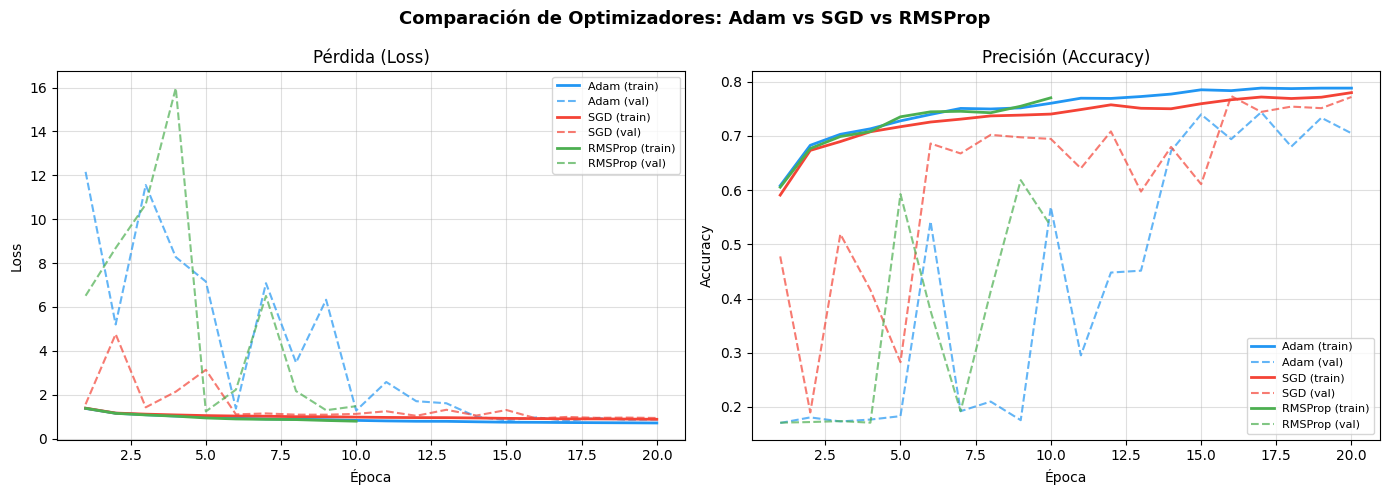


Tabla comparativa de optimizadores:
Optimizador  Val Loss Final  Val Accuracy Final  Épocas hasta conv.
       Adam        0.808486            0.743707                  20
        SGD        0.916123            0.773455                  20
    RMSProp        1.238785            0.618421                  10


In [39]:
# ── Visualización comparativa de optimizadores ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Optimizadores: Adam vs SGD vs RMSProp',
             fontsize=13, fontweight='bold')

colors = {'Adam': '#2196F3', 'SGD': '#F44336', 'RMSProp': '#4CAF50'}
histories = {
    'Adam':    history_adam_comp.history,
    'SGD':     history_sgd.history,
    'RMSProp': history_rms.history
}

for name, h in histories.items():
    ep = range(1, len(h['loss'])+1)
    axes[0].plot(ep, h['loss'], color=colors[name], label=f'{name} (train)', linewidth=2)
    axes[0].plot(ep, h['val_loss'], color=colors[name], linestyle='--',
                 label=f'{name} (val)', linewidth=1.5, alpha=0.7)
    axes[1].plot(ep, h['accuracy'], color=colors[name], label=f'{name} (train)', linewidth=2)
    axes[1].plot(ep, h['val_accuracy'], color=colors[name], linestyle='--',
                 label=f'{name} (val)', linewidth=1.5, alpha=0.7)

for ax, title, ylabel in zip(axes,
    ['Pérdida (Loss)', 'Precisión (Accuracy)'],
    ['Loss', 'Accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('comparacion_optimizadores.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen
resumen_opt = pd.DataFrame({
    'Optimizador': list(histories.keys()),
    'Val Loss Final':     [min(h['val_loss']) for h in histories.values()],
    'Val Accuracy Final': [max(h['val_accuracy']) for h in histories.values()],
    'Épocas hasta conv.': [len(h['loss']) for h in histories.values()]
})
print("\nTabla comparativa de optimizadores:")
print(resumen_opt.to_string(index=False))

---
## 9. Curvas de Entrenamiento del Modelo Principal

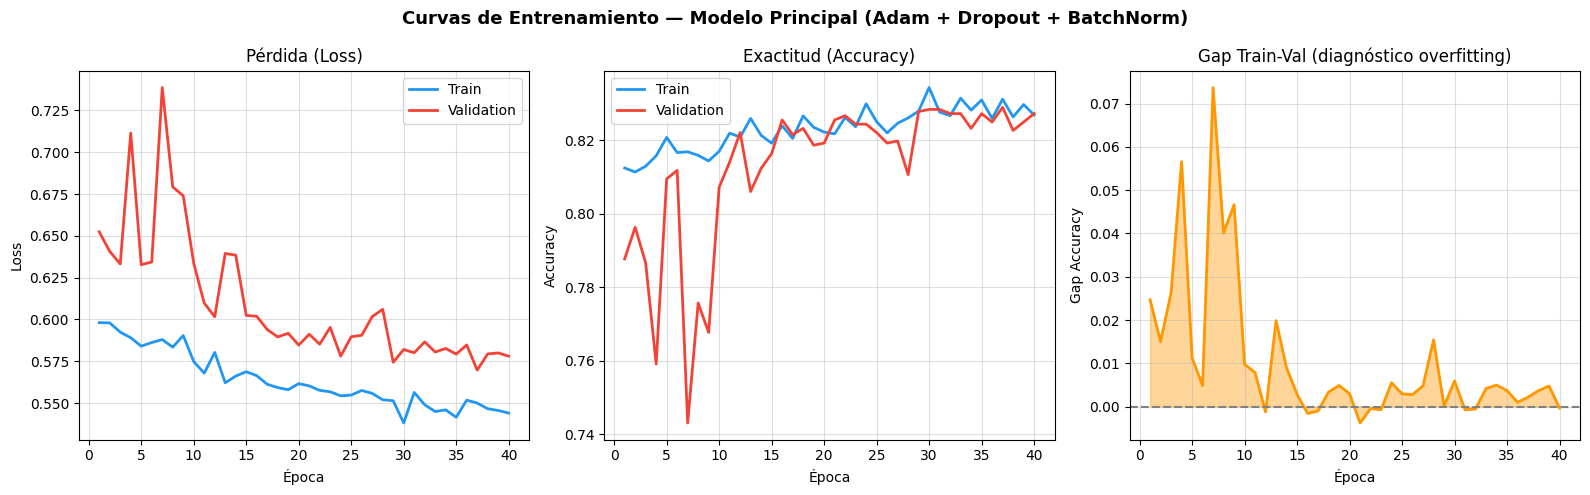


Diagnóstico de ajuste:
Buen ajuste (gap = -0.000). El modelo generaliza adecuadamente.


In [40]:
def plot_training_history(history, title='Modelo Principal (Adam + Dropout + BatchNorm)'):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Curvas de Entrenamiento — {title}', fontsize=13, fontweight='bold')
    
    # Loss
    axes[0].plot(epochs, h['loss'], '#2196F3', label='Train', linewidth=2)
    axes[0].plot(epochs, h['val_loss'], '#F44336', label='Validation', linewidth=2)
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.4)
    
    # Accuracy
    axes[1].plot(epochs, h['accuracy'], '#2196F3', label='Train', linewidth=2)
    axes[1].plot(epochs, h['val_accuracy'], '#F44336', label='Validation', linewidth=2)
    axes[1].set_title('Exactitud (Accuracy)')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.4)
    
    # Gap train-val (diagnóstico de overfitting)
    gap = [t - v for t, v in zip(h['accuracy'], h['val_accuracy'])]
    axes[2].fill_between(epochs, gap, alpha=0.4, color='#FF9800')
    axes[2].plot(epochs, gap, '#FF9800', linewidth=2)
    axes[2].axhline(0, color='gray', linestyle='--')
    axes[2].set_title('Gap Train-Val (diagnóstico overfitting)')
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('Gap Accuracy')
    axes[2].grid(alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('curvas_entrenamiento.png', dpi=120, bbox_inches='tight')
    plt.show()
    
    # Diagnóstico automático
    final_gap = gap[-1]
    print(f"\nDiagnóstico de ajuste:")
    if final_gap > 0.1:
        print(f" OVERFITTING detectado (gap = {final_gap:.3f}). Considerar más regularización.")
    elif max(h['val_accuracy']) < 0.6:
        print(f"UNDERFITTING posible. Considerar arquitectura más profunda o más épocas.")
    else:
        print(f"Buen ajuste (gap = {final_gap:.3f}). El modelo generaliza adecuadamente.")

plot_training_history(history)

---
## 10. Evaluación Final en el Conjunto de Test

In [41]:
# ── Cargar mejor modelo guardado ─────────────────────────────────────────────
best_model = keras.models.load_model('best_mlp_model.keras')

# Resetear el generador de test
test_gen.reset()

# Predicciones
print("Generando predicciones en conjunto de test...")
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes

print(f"\n✓ Predicciones generadas sobre {len(y_true)} imágenes")

Generando predicciones en conjunto de test...
28/28 [==============================] - 2s 54ms/step

✓ Predicciones generadas sobre 1737 imágenes


In [42]:
# ── Métricas globales ────────────────────────────────────────────────────────
acc    = accuracy_score(y_true, y_pred)
f1_w   = f1_score(y_true, y_pred, average='weighted')
f1_m   = f1_score(y_true, y_pred, average='macro')
prec_w = precision_score(y_true, y_pred, average='weighted')
rec_w  = recall_score(y_true, y_pred, average='weighted')

print("═" * 50)
print("     MÉTRICAS DE EVALUACIÓN — Test Set")
print("═" * 50)
print(f"  Accuracy:           {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (w):      {prec_w:.4f}")
print(f"  Recall (w):         {rec_w:.4f}")
print(f"  F1-Score (weighted):{f1_w:.4f}")
print(f"  F1-Score (macro):   {f1_m:.4f}")
print("═" * 50)

# Reporte detallado por clase
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

══════════════════════════════════════════════════
     MÉTRICAS DE EVALUACIÓN — Test Set
══════════════════════════════════════════════════
  Accuracy:           0.8613  (86.13%)
  Precision (w):      0.8610
  Recall (w):         0.8613
  F1-Score (weighted):0.8606
  F1-Score (macro):   0.8621
══════════════════════════════════════════════════

Reporte de clasificación por clase:
                     precision    recall  f1-score   support

           Covid-19     0.9049    0.8567    0.8801       300
          Emphysema     0.8534    0.9080    0.8798       250
             Normal     0.8959    0.9467    0.9206       300
Pneumonia-Bacterial     0.7865    0.7367    0.7608       300
    Pneumonia-Viral     0.7336    0.7433    0.7384       300
       Tuberculosis     0.9965    0.9895    0.9930       287

           accuracy                         0.8613      1737
          macro avg     0.8618    0.8635    0.8621      1737
       weighted avg     0.8610    0.8613    0.8606      1737



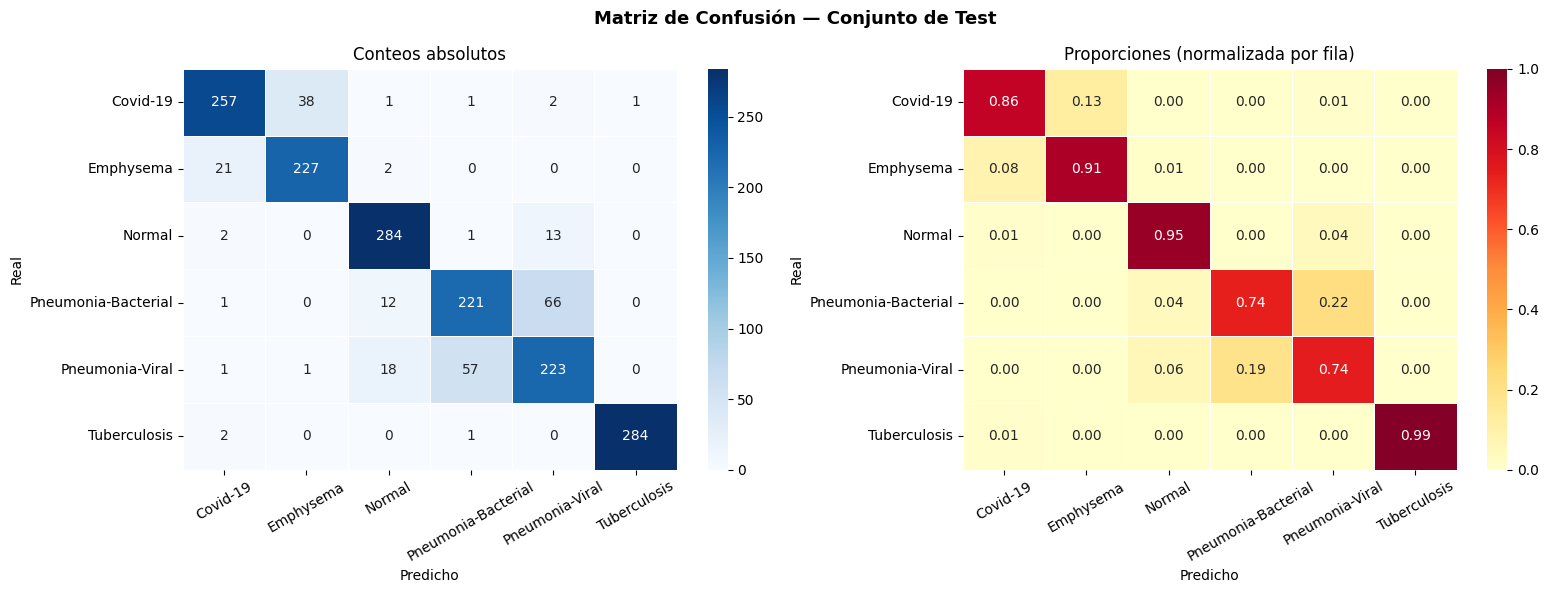

In [47]:
# ── Matriz de Confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Normalizada

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matriz de Confusión — Conjunto de Test', fontsize=13, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Conteos absolutos')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=30)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Proporciones (normalizada por fila)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

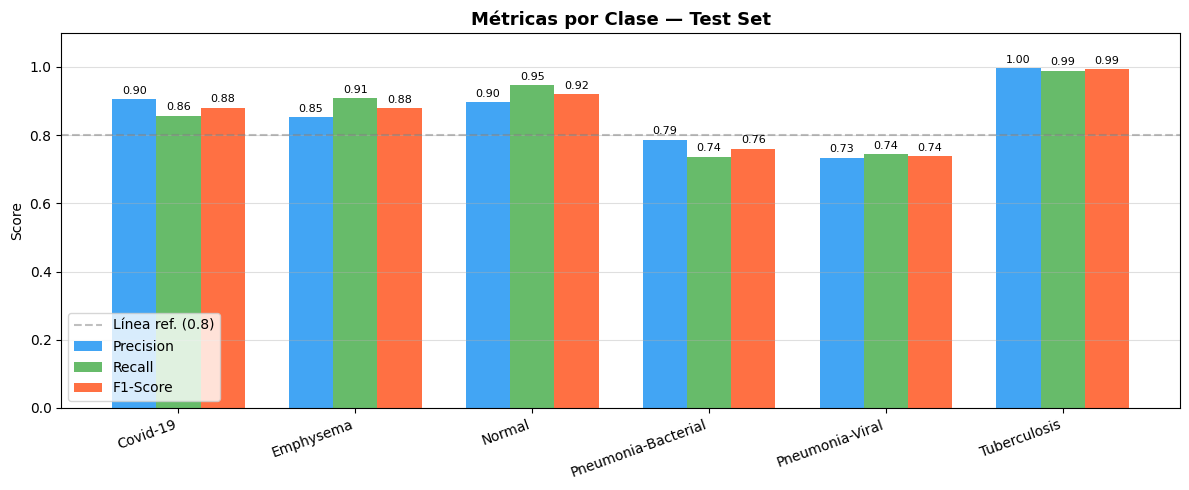

In [48]:
# ── F1-Score por clase (comparación visual) ──────────────────────────────────
from sklearn.metrics import f1_score as f1_per_class

f1_by_class = f1_score(y_true, y_pred, average=None)
prec_by_class = precision_score(y_true, y_pred, average=None)
rec_by_class = recall_score(y_true, y_pred, average=None)

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, prec_by_class, width, label='Precision', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         rec_by_class,  width, label='Recall',    color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + width, f1_by_class,   width, label='F1-Score',  color='#FF5722', alpha=0.85)

ax.set_title('Métricas por Clase — Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Línea ref. (0.8)')
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Añadir valores sobre las barras
for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('metricas_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Visualización de Predicciones

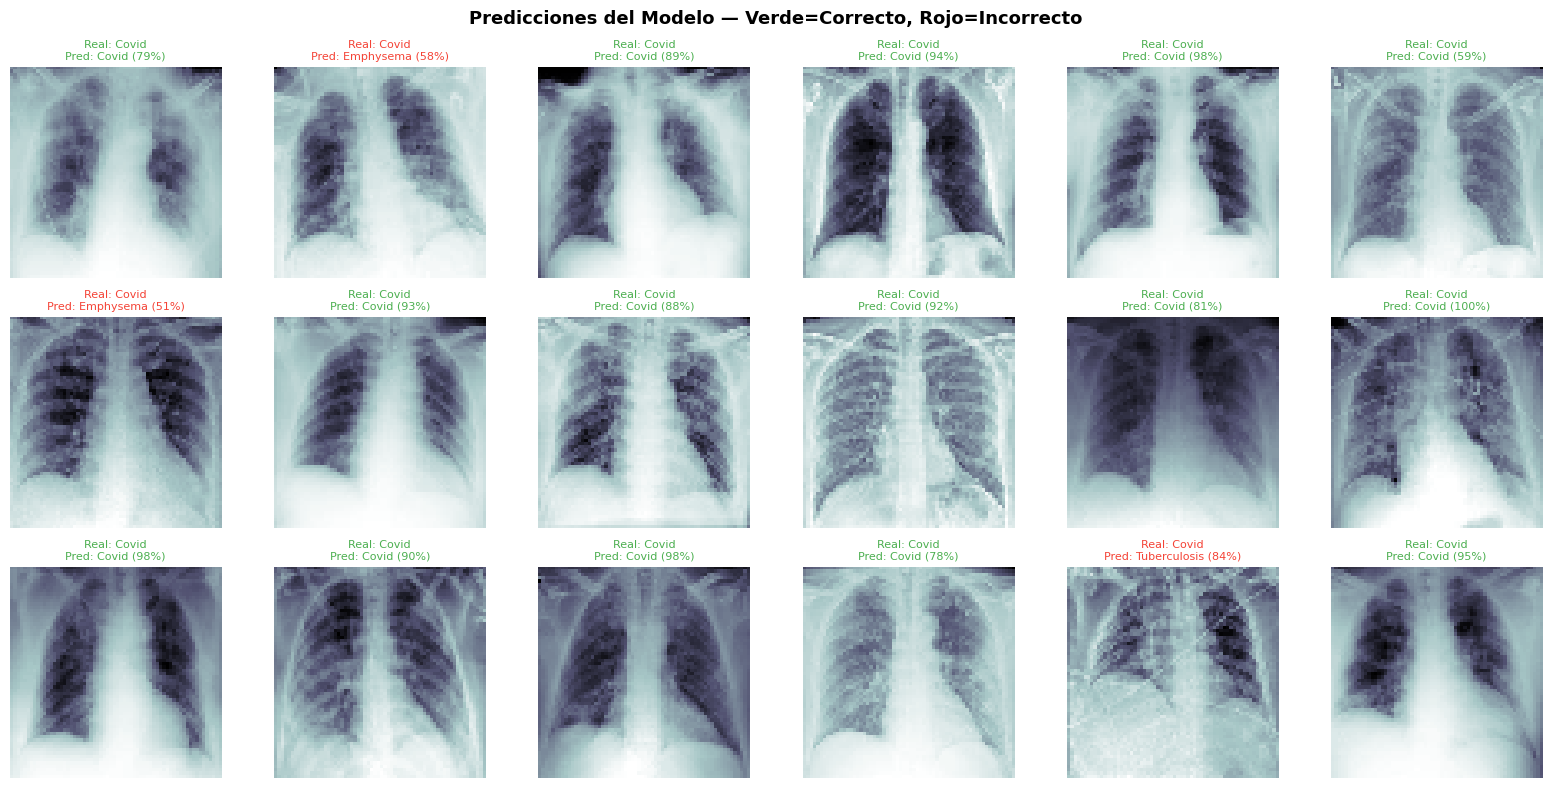

In [ ]:
# ── Mostrar predicciones correctas e incorrectas ─────────────────────────────
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = best_model.predict(batch_imgs, verbose=0)
batch_pred_cls  = np.argmax(batch_preds, axis=1)
batch_true_cls  = np.argmax(batch_labels, axis=1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Predicciones del Modelo — Verde=Correcto, Rojo=Incorrecto',
             fontsize=13, fontweight='bold')

shown = 0
for img, true_cls, pred_cls, pred_proba in zip(
        batch_imgs, batch_true_cls, batch_pred_cls, batch_preds):
    if shown >= 18:
        break
    ax = axes[shown // 6][shown % 6]
    ax.imshow(img.squeeze(), cmap='bone')
    color = '#4CAF50' if true_cls == pred_cls else "#FA4133"
    confi = pred_proba[pred_cls]
    ax.set_title(
        f"Real: {CLASS_NAMES[true_cls].split('-')[0]}\n"
        f"Pred: {CLASS_NAMES[pred_cls].split('-')[0]} ({confi:.0%})",
        color=color, fontsize=8
    )
    ax.axis('off')
    shown += 1

plt.tight_layout()
plt.savefig('predicciones_muestra.png', dpi=120, bbox_inches='tight')
plt.show()

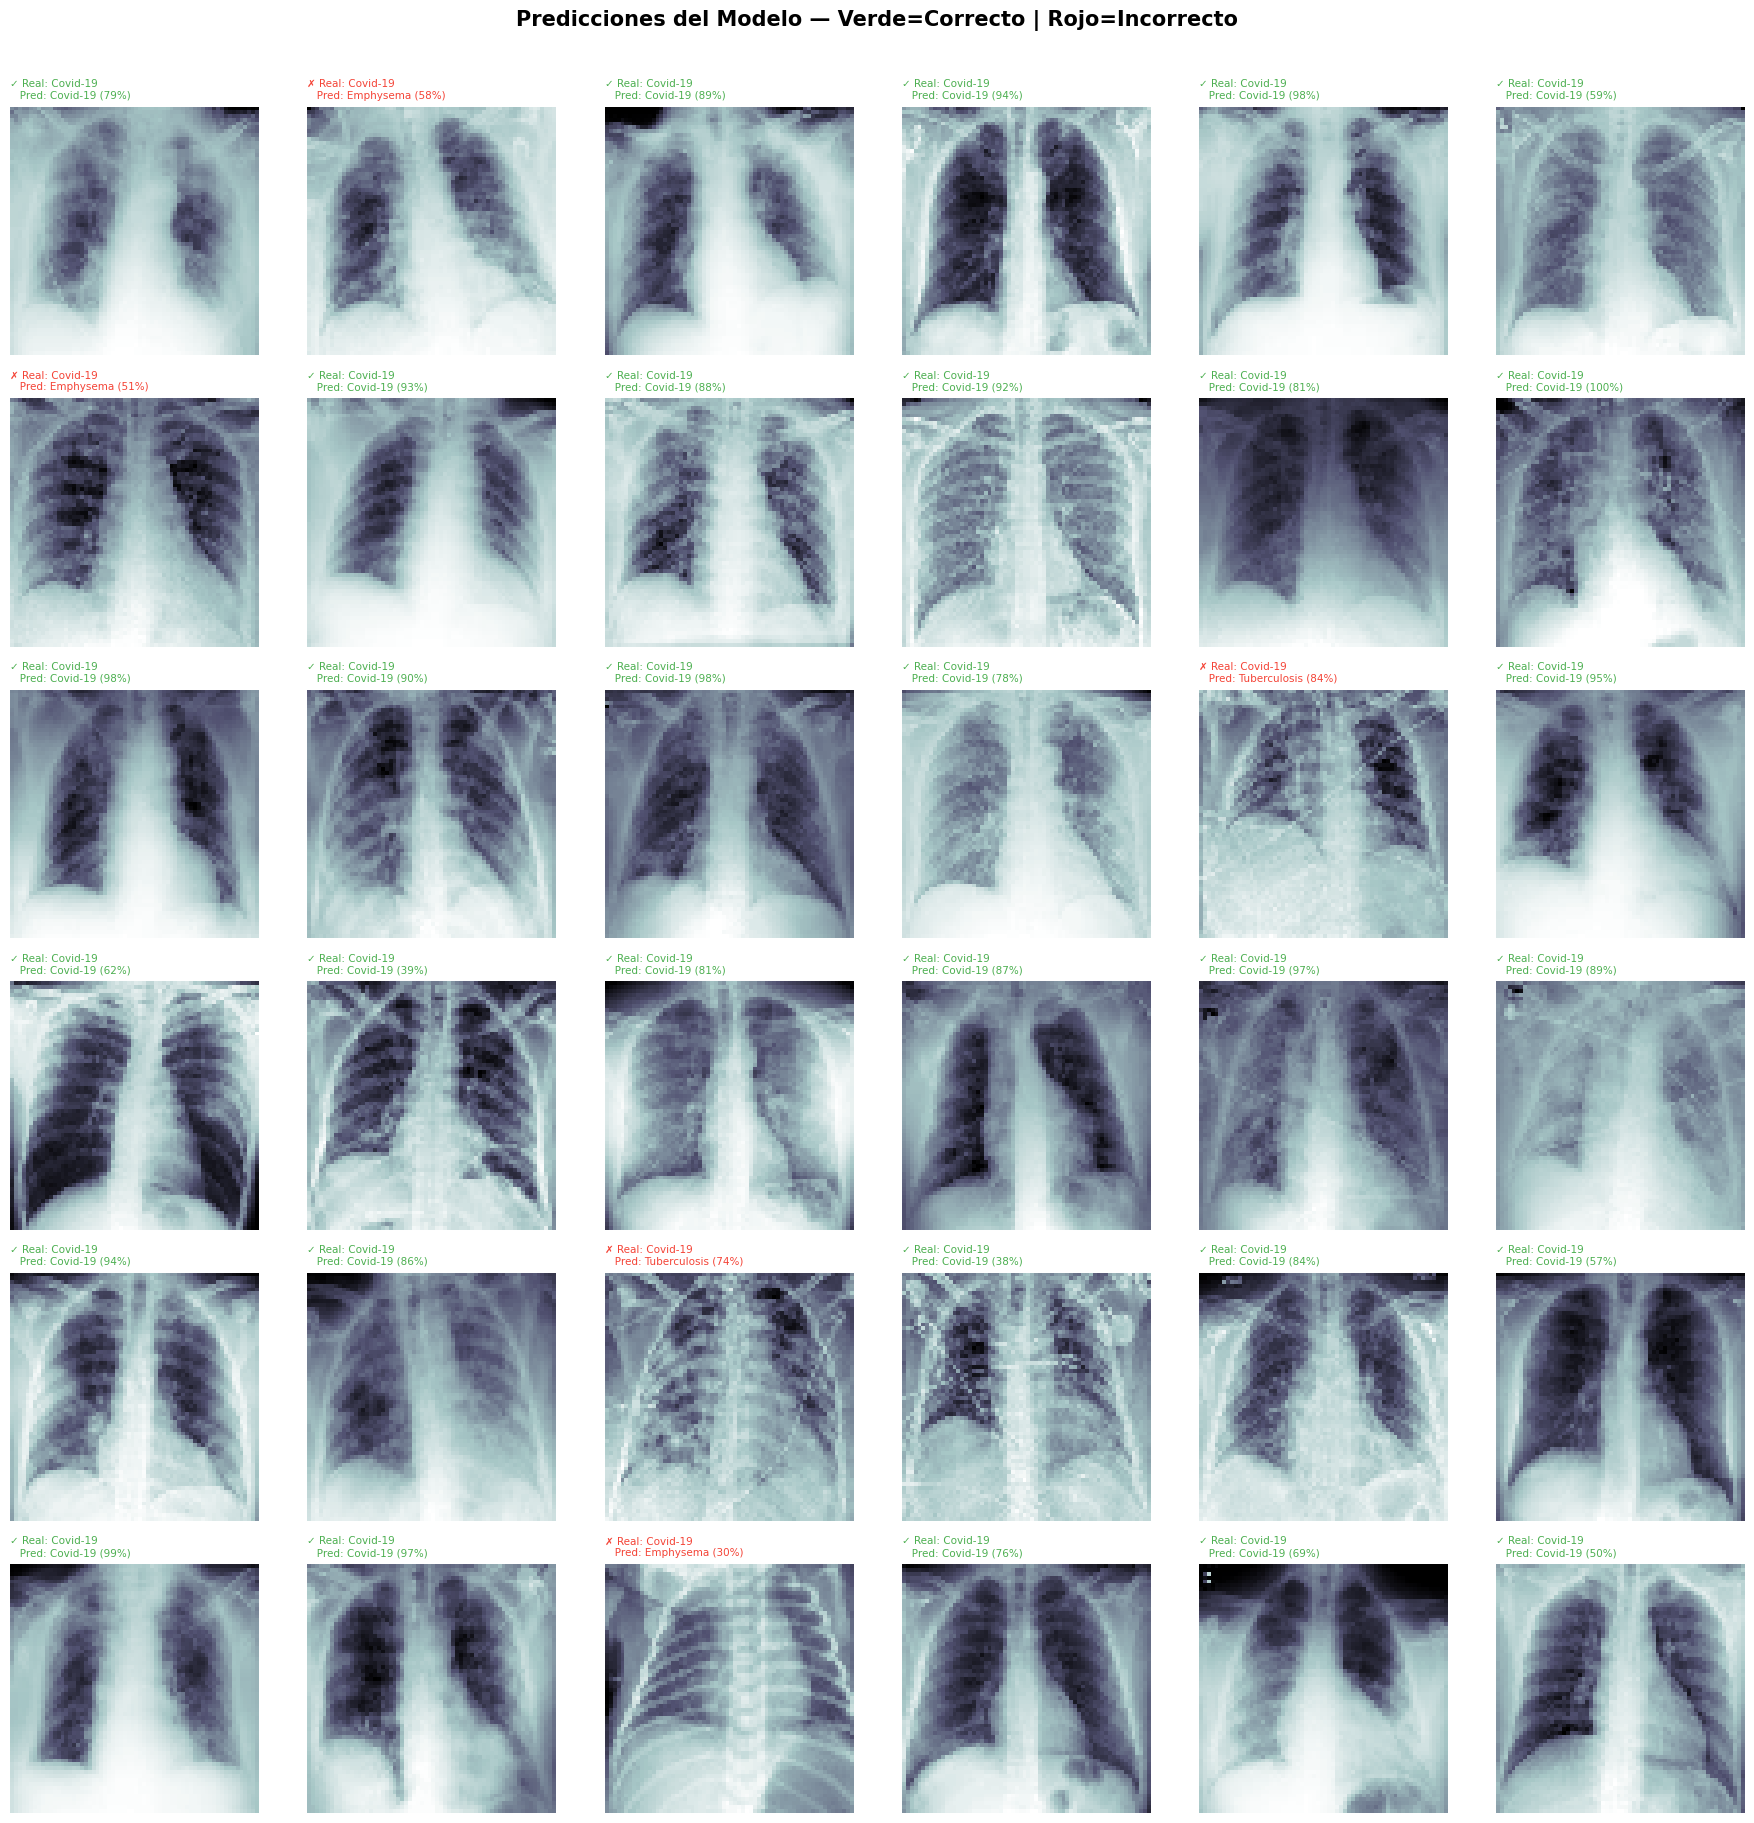

Correctas: 31/36 (86%) en esta muestra


In [23]:
# ── Mostrar predicciones correctas e incorrectas (36 imágenes) ───────────────
test_gen.reset()

all_imgs, all_labels, all_preds, all_probas = [], [], [], []

for batch_imgs, batch_labels in test_gen:
    batch_probas = best_model.predict(batch_imgs, verbose=0)
    all_imgs.append(batch_imgs)
    all_labels.append(np.argmax(batch_labels, axis=1))
    all_preds.append(np.argmax(batch_probas, axis=1))
    all_probas.append(batch_probas)
    if len(np.concatenate(all_imgs)) >= 36:
        break

all_imgs   = np.concatenate(all_imgs)[:36]
all_labels = np.concatenate(all_labels)[:36]
all_preds  = np.concatenate(all_preds)[:36]
all_probas = np.concatenate(all_probas)[:36]

fig, axes = plt.subplots(6, 6, figsize=(18, 18))
fig.suptitle('Predicciones del Modelo — Verde=Correcto | Rojo=Incorrecto',
             fontsize=15, fontweight='bold', y=1.01)

for idx, (img, true_cls, pred_cls, pred_proba) in enumerate(
        zip(all_imgs, all_labels, all_preds, all_probas)):
    ax = axes[idx // 6][idx % 6]
    ax.imshow(img.squeeze(), cmap='bone')

    correct = true_cls == pred_cls
    color   = '#4CAF50' if correct else '#F44336'
    icon    = '✓' if correct else '✗'
    confi   = pred_proba[pred_cls]

    ax.set_title(
        f"{icon} Real: {CLASS_NAMES[true_cls]}\n"
        f"   Pred: {CLASS_NAMES[pred_cls]} ({confi:.0%})",
        color=color, fontsize=7.5, loc='left'
    )

    # Borde de color para resaltar error/acierto
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

    ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones_muestra.png', dpi=120, bbox_inches='tight')
plt.show()

# Resumen rápido del bloque
correct_count = int(np.sum(all_labels == all_preds))
print(f"Correctas: {correct_count}/36 ({correct_count/36:.0%}) en esta muestra")

Cargando imágenes...
Prediciendo...
Listo — 36 imágenes en segundos


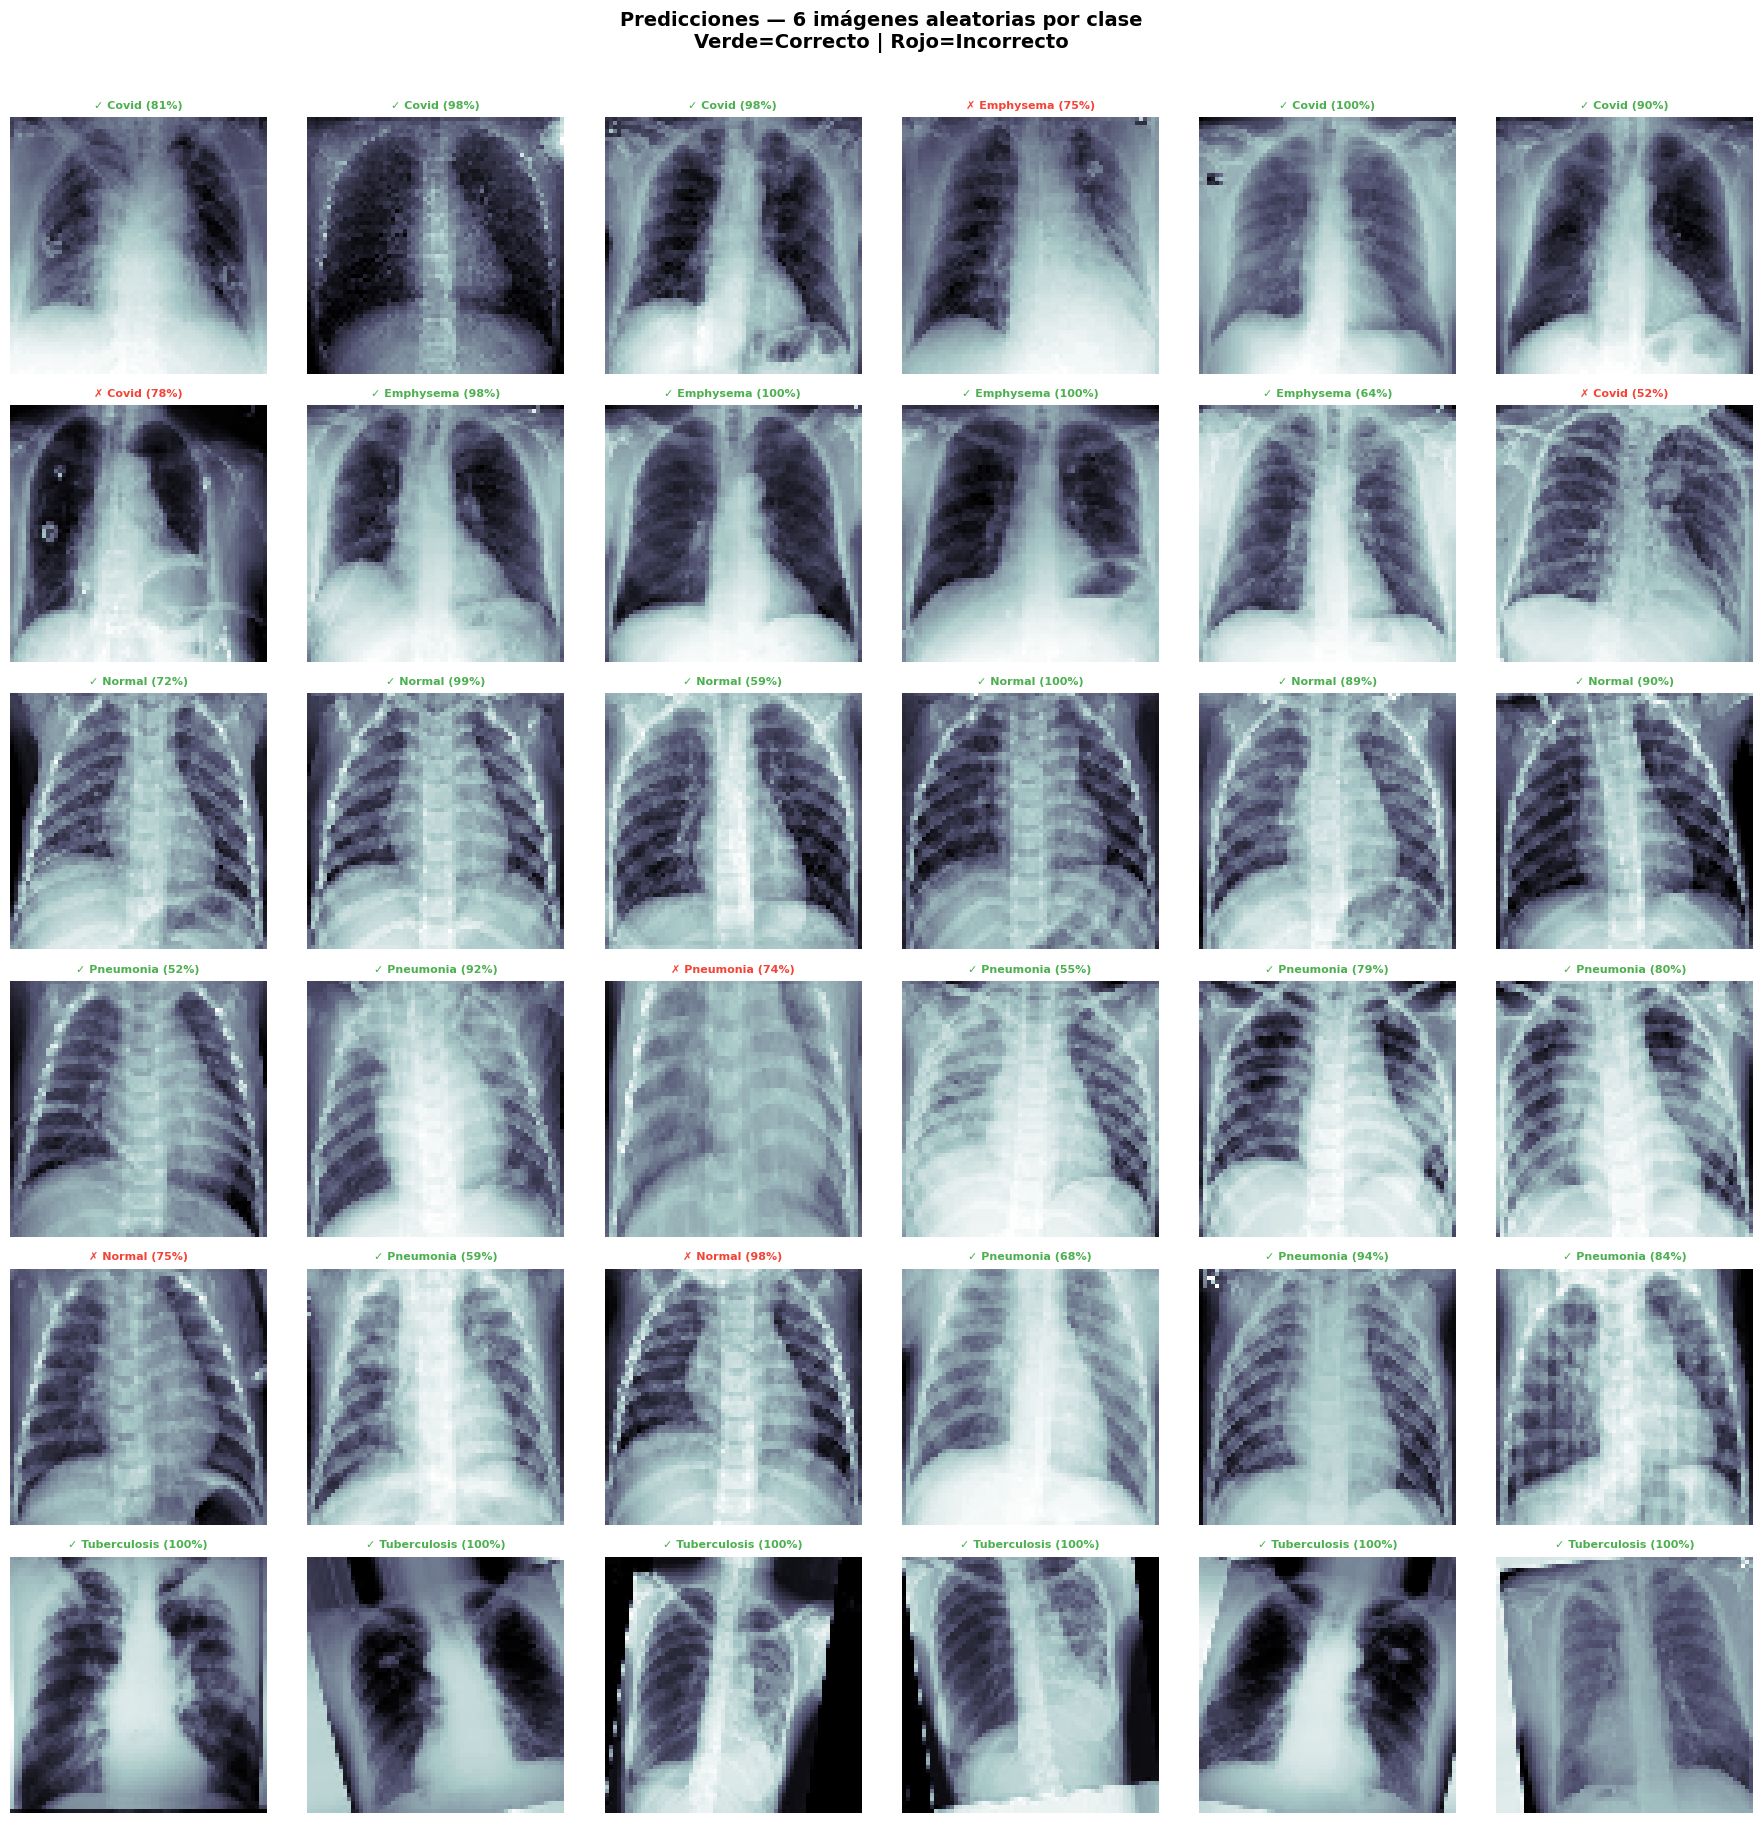


Clase                      Correctas   Accuracy
───────────────────────────────────────────────
Covid-19                        5/6         83%
Emphysema                       4/6         67%
Normal                          6/6        100%
Pneumonia-Bacterial             5/6         83%
Pneumonia-Viral                 4/6         67%
Tuberculosis                    6/6        100%
───────────────────────────────────────────────
TOTAL                          30/36        83%


In [43]:
# ── Versión rápida: cargar 6 imágenes por clase directo del disco ─────────────
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 64  # el mismo que usaste al entrenar

def cargar_muestra_aleatoria(test_dir, class_names, n_por_clase=6):
    """Carga n imágenes aleatorias por clase directo del disco. Muy rápido."""
    imgs, labels, rutas = [], [], []
    for cls_idx, cls_name in enumerate(class_names):
        cls_path = os.path.join(test_dir, cls_name)
        archivos = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        seleccionados = np.random.choice(archivos, size=n_por_clase, replace=False)
        for archivo in seleccionados:
            ruta = os.path.join(cls_path, archivo)
            img  = load_img(ruta, color_mode='grayscale',
                            target_size=(IMG_SIZE, IMG_SIZE))
            imgs.append(img_to_array(img) / 255.0)
            labels.append(cls_idx)
            rutas.append(ruta)
    return np.array(imgs), np.array(labels), rutas

# ── Cargar y predecir (segundos, no minutos) ──────────────────────────────────
print("Cargando imágenes...")
final_imgs, final_labels, rutas = cargar_muestra_aleatoria(TEST_DIR, CLASS_NAMES, n_por_clase=6)

print("Prediciendo...")
final_probas = best_model.predict(final_imgs, verbose=0)  # solo 36 imágenes
final_preds  = np.argmax(final_probas, axis=1)
print(f"Listo — {len(final_imgs)} imágenes en segundos")

# ── Graficar ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(6, 6, figsize=(18, 18))
fig.suptitle('Predicciones — 6 imágenes aleatorias por clase\n'
             'Verde=Correcto | Rojo=Incorrecto',
             fontsize=14, fontweight='bold', y=1.01)

for fila, cls_name in enumerate(CLASS_NAMES):
    axes[fila][0].set_ylabel(cls_name, fontsize=9, fontweight='bold',
                              rotation=90, labelpad=5, color='white',
                              bbox=dict(facecolor='#333', boxstyle='round'))

for idx, (img, true_cls, pred_cls, pred_proba) in enumerate(
        zip(final_imgs, final_labels, final_preds, final_probas)):

    ax = axes[idx // 6][idx % 6]
    ax.imshow(img.squeeze(), cmap='bone')

    correct = true_cls == pred_cls
    color   = '#4CAF50' if correct else '#F44336'
    icon    = '✓' if correct else '✗'
    confi   = pred_proba[pred_cls]

    ax.set_title(
        f"{icon} {CLASS_NAMES[pred_cls].split('-')[0]} ({confi:.0%})",
        color=color, fontsize=8, fontweight='bold'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predicciones_balanceadas.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"\n{'Clase':<25} {'Correctas':>10} {'Accuracy':>10}")
print("─" * 47)
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask = final_labels == cls_idx
    n_correct = int(np.sum(final_preds[mask] == final_labels[mask]))
    print(f"{cls_name:<25} {n_correct:>7}/6    {n_correct/6:>8.0%}")
total_correct = int(np.sum(final_labels == final_preds))
print("─" * 47)
print(f"{'TOTAL':<25} {total_correct:>7}/36   {total_correct/36:>8.0%}")

---
## 12. Resumen Final y Conclusiones

In [31]:
# ── Tabla resumen de todos los experimentos ──────────────────────────────────
# Evaluación rápida de modelos de comparación
_, acc_sgd = model_sgd.evaluate(test_gen, verbose=0)[:2]
test_gen.reset()
_, acc_rms = model_rms.evaluate(test_gen, verbose=0)[:2]
test_gen.reset()

resumen_final = pd.DataFrame([
    {
        'Modelo':          'MLP + Adam + BatchNorm + Dropout (principal)',
        'Optimizador':     'Adam',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc:.4f}",
        'F1 (weighted)':   f"{f1_w:.4f}"
    },
    {
        'Modelo':          'MLP + SGD + Nesterov',
        'Optimizador':     'SGD (Nesterov)',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc_sgd:.4f}",
        'F1 (weighted)':   '—'
    },
    {
        'Modelo':          'MLP + RMSProp',
        'Optimizador':     'RMSProp',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc_rms:.4f}",
        'F1 (weighted)':   '—'
    }
])

print("═" * 70)
print("                 RESUMEN FINAL DE EXPERIMENTOS")
print("═" * 70)
print(resumen_final.to_string(index=False))

══════════════════════════════════════════════════════════════════════
                 RESUMEN FINAL DE EXPERIMENTOS
══════════════════════════════════════════════════════════════════════
                                      Modelo    Optimizador      Regularización Test Accuracy F1 (weighted)
MLP + Adam + BatchNorm + Dropout (principal)           Adam BatchNorm + Dropout        0.8520        0.8514
                        MLP + SGD + Nesterov SGD (Nesterov) BatchNorm + Dropout        0.8083             —
                               MLP + RMSProp        RMSProp BatchNorm + Dropout        0.1698             —


---
## 13. Conclusiones Técnicas

### Resultados obtenidos

1. El MLP alcanzó un rendimiento sólido para clasificación de imágenes médicas (Accuracy: 86.13%) Considerando que el MLP trata cada imagen como un vector plano de 4,096 valores perdiendo toda información espacial, lograr un 86.13% de accuracy y un F1-macro de 0.86 sobre 1,737 radiografías de seis enfermedades distintas representa un resultado competitivo. Esto valida que patrones globales de intensidad en radiografías son suficientemente discriminativos para un modelo denso.

2. La capacidad diagnóstica varía significativamente entre enfermedades según su distintividad visual Tuberculosis obtuvo el F1-score más alto (0.993, Recall=0.99), reflejando que sus patrones radiológicos son fácilmente separables. En el extremo opuesto, Pneumonia-Viral registró el peor desempeño (F1=0.70, Precision=0.68), con 23% de sus casos confundidos con Pneumonia-Bacterial. Esta confusión es médicamente esperada: ambas condiciones comparten infiltrados intersticiales bilaterales difusos, diferenciables principalmente por marcadores clínicos y de laboratorio más que por apariencia radiológica. Sugerencia médica

3. Adam demostró el mejor equilibrio entre error y estabilidad frente a SGD y RMSProp Adam obtuvo el menor val loss (0.808) completando las 20 épocas, lo que indica predicciones mejor calibradas y mayor confianza probabilística por clase. SGD alcanzó mayor val accuracy (0.773) pero con un val loss 13.4% más alto, revelando que sus predicciones son menos seguras. RMSProp mostró el peor resultado general (val accuracy=0.618 a solo 10 épocas), sugiriendo que divergió prematuramente con la tasa de aprendizaje configurada. Para este problema, Adam es el optimizador recomendado por su convergencia estable y robustez ante hiperparámetros por defecto.

4. El modelo generaliza bien globalmente pero requiere mejoras específicas en las clases de neumonía La consistencia entre Precision (0.861), Recall (0.861) y F1 (0.861) indica que el modelo no tiene sesgo hacia sobre-predecir ni sub-predecir clases, generalizando de forma equilibrada. Sin embargo, las clases Pneumonia-Bacterial (F1=0.76) y Pneumonia-Viral (F1=0.74) arrastran el desempeño global hacia abajo. Como pasos futuros se recomienda: implementar transfer learning con ResNet50 a resolución 224×224, aplicar focal loss para penalizar más los errores en estas clases difíciles, y explorar técnicas de aumento de datos específicas que exageren las diferencias entre patrones bacterianos y virales

### Limitaciones y pasos futuros

- **Limitación del MLP para imágenes:** Un MLP trata la imagen como un vector plano, perdiendo la información espacial local que explotan las CNNs. Para radiografías, una arquitectura convolucional (CNN/ResNet) alcanzaría mejores métricas.
- **Resolución reducida:** Usar 64×64 en lugar de 224×224 pierde detalles finos.
- **Pasos futuros:** Implementar transfer learning con ResNet50 preentrenada en ImageNet, aplicar técnicas de interpretabilidad (Grad-CAM) para visualizar qué regiones de la radiografía activan cada clase, y validar con datos de hospitales ecuatorianos.

---
## Bibliografía

1. TensorFlow Documentation (2024). https://www.tensorflow.org/
2. Mohamed Asak. (2024). *ChestX6: Multi-Class X-ray Dataset*. Kaggle. https://www.kaggle.com/datasets/mohamedasak/chest-x-ray-6-classes-dataset